# Train Logistic Regression on Sign Count Concepts

This notebook trains a multivariate logistic-regression classifier on the sample-level TCAV `sign_count` concept vectors.
It uses an 80/20 split over shared speakers inside each `system_id`, so spoof and bonafide remain paired per system while avoiding speaker leakage.


In [1]:
import json
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler


In [2]:
# ===== Config =====
PROJECT_ROOT = Path('/home/SpeakerRec/BioVoice')
TCAV_ROOT = PROJECT_ROOT / 'redimnet' / 'tcav' / 'captum_tcav' / 'asvspoof5'
OUTPUT_SUBDIR = 'subset_20spk_20utts_per_spk_one_logistic_head'
OUTPUT_DIR = TCAV_ROOT / 'output' / OUTPUT_SUBDIR

INPUT_CSV = OUTPUT_DIR / 'merged_tcav_sign_count_wide.csv'
MODEL_OUT_DIR = OUTPUT_DIR / 'sign_count_logistic_results'
MODEL_OUT_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDE_A12 = False
TEST_FRACTION = 0.2
RANDOM_SEED = 42
LOGREG_MAX_ITER = 2000
LOGREG_C = 1.0

print('INPUT_CSV =', INPUT_CSV)
print('Exists =', INPUT_CSV.exists())
print('MODEL_OUT_DIR =', MODEL_OUT_DIR)


INPUT_CSV = /home/SpeakerRec/BioVoice/redimnet/tcav/captum_tcav/asvspoof5/output/subset_20spk_20utts_per_spk_one_logistic_head/merged_tcav_sign_count_wide.csv
Exists = True
MODEL_OUT_DIR = /home/SpeakerRec/BioVoice/redimnet/tcav/captum_tcav/asvspoof5/output/subset_20spk_20utts_per_spk_one_logistic_head/sign_count_logistic_results


In [3]:
df = pd.read_csv(INPUT_CSV)

if EXCLUDE_A12:
    df = df[df['system_id'] != 'A12'].copy()

meta_cols = ['utt_id', 'speaker_id', 'split', 'source_partition', 'system_id', 'target_class', 'binary_label']
feature_cols = [c for c in df.columns if c not in meta_cols]

print('Rows =', len(df))
print('Speakers =', df['speaker_id'].nunique())
print('Systems =', sorted(df['system_id'].unique().tolist()))
print('Feature columns =', len(feature_cols))
display(df.head())


Rows = 12800
Speakers = 81
Systems = ['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16']
Feature columns = 12


,utt_id,speaker_id,split,source_partition,system_id,target_class,binary_label,long_constant_thick,long_dropping_flat_thick,long_dropping_steep_thick,long_dropping_steep_thin,long_rising_flat_thick,long_rising_steep_thick,long_rising_steep_thin,short_constant_thick,short_dropping_steep_thick,short_dropping_steep_thin,short_rising_steep_thick,short_rising_steep_thin
0,D_0000036016,D_0430,test,dev,A09,bonafide,0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,D_0000207208,D_0430,test,dev,A09,bonafide,0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
2,D_0000313804,D_0430,test,dev,A09,bonafide,0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,D_0000437998,D_0430,test,dev,A09,bonafide,0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,D_0000438019,D_0430,test,dev,A09,bonafide,0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [4]:
rng = np.random.default_rng(RANDOM_SEED)
train_parts = []
test_parts = []
split_summary_rows = []

for system_id in sorted(df['system_id'].unique()):
    sys_df = df[df['system_id'] == system_id].copy()
    spoof_speakers = set(sys_df.loc[sys_df['target_class'] == 'spoof', 'speaker_id'].unique().tolist())
    bonafide_speakers = set(sys_df.loc[sys_df['target_class'] == 'bonafide', 'speaker_id'].unique().tolist())
    shared_speakers = np.array(sorted(spoof_speakers.intersection(bonafide_speakers)), dtype=object)

    if len(shared_speakers) < 2:
        raise RuntimeError(f'Not enough shared speakers for system {system_id}: {len(shared_speakers)}')

    rng.shuffle(shared_speakers)
    n_test = max(1, int(round(len(shared_speakers) * TEST_FRACTION)))
    if n_test >= len(shared_speakers):
        n_test = len(shared_speakers) - 1

    test_speakers = set(shared_speakers[:n_test].tolist())
    train_speakers = set(shared_speakers[n_test:].tolist())

    sys_train_df = sys_df[sys_df['speaker_id'].isin(train_speakers)].copy()
    sys_test_df = sys_df[sys_df['speaker_id'].isin(test_speakers)].copy()

    train_parts.append(sys_train_df)
    test_parts.append(sys_test_df)

    split_summary_rows.append({
        'system_id': system_id,
        'shared_speakers_total': int(len(shared_speakers)),
        'train_speakers': int(len(train_speakers)),
        'test_speakers': int(len(test_speakers)),
        'train_rows': int(len(sys_train_df)),
        'test_rows': int(len(sys_test_df)),
        'train_spoof_rows': int((sys_train_df['binary_label'] == 1).sum()),
        'train_bonafide_rows': int((sys_train_df['binary_label'] == 0).sum()),
        'test_spoof_rows': int((sys_test_df['binary_label'] == 1).sum()),
        'test_bonafide_rows': int((sys_test_df['binary_label'] == 0).sum()),
    })

split_check_df = pd.DataFrame(split_summary_rows).sort_values('system_id').reset_index(drop=True)
display(split_check_df)

train_df = pd.concat(train_parts, axis=0, ignore_index=True)
test_df = pd.concat(test_parts, axis=0, ignore_index=True)

train_keys = set(zip(train_df['system_id'], train_df['speaker_id']))
test_keys = set(zip(test_df['system_id'], test_df['speaker_id']))
assert train_keys.isdisjoint(test_keys), 'System-speaker leakage detected'

print('Train rows =', len(train_df))
print('Test rows =', len(test_df))
print('Train class counts:')
print(train_df['binary_label'].value_counts().sort_index())
print('Test class counts:')
print(test_df['binary_label'].value_counts().sort_index())


,system_id,shared_speakers_total,train_speakers,test_speakers,train_rows,test_rows,train_spoof_rows,train_bonafide_rows,test_spoof_rows,test_bonafide_rows
0,A01,20,16,4,640,160,320,320,80,80
1,A02,20,16,4,640,160,320,320,80,80
2,A03,20,16,4,640,160,320,320,80,80
3,A04,20,16,4,640,160,320,320,80,80
4,A05,20,16,4,640,160,320,320,80,80
5,A06,20,16,4,640,160,320,320,80,80
6,A07,20,16,4,640,160,320,320,80,80
7,A08,20,16,4,640,160,320,320,80,80
8,A09,20,16,4,640,160,320,320,80,80
9,A10,20,16,4,640,160,320,320,80,80


Train rows = 10240
Test rows = 2560
Train class counts:
0    5120
1    5120
Name: binary_label, dtype: int64
Test class counts:
0    1280
1    1280
Name: binary_label, dtype: int64


In [5]:
X_tr = train_df[feature_cols].to_numpy(dtype=float)
y_tr = train_df['binary_label'].to_numpy(dtype=int)
X_te = test_df[feature_cols].to_numpy(dtype=float)
y_te = test_df['binary_label'].to_numpy(dtype=int)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

clf = LogisticRegression(
    max_iter=LOGREG_MAX_ITER,
    C=LOGREG_C,
    class_weight=None,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
clf.fit(X_tr_s, y_tr)

p_tr = clf.predict_proba(X_tr_s)[:, 1]
p_te = clf.predict_proba(X_te_s)[:, 1]
yhat_tr = (p_tr >= 0.5).astype(int)
yhat_te = (p_te >= 0.5).astype(int)

summary = {
    'train_accuracy': float(accuracy_score(y_tr, yhat_tr)),
    'test_accuracy': float(accuracy_score(y_te, yhat_te)),
    'train_auc': float(roc_auc_score(y_tr, p_tr)),
    'test_auc': float(roc_auc_score(y_te, p_te)),
    'train_confusion_matrix': confusion_matrix(y_tr, yhat_tr).tolist(),
    'test_confusion_matrix': confusion_matrix(y_te, yhat_te).tolist(),
    'train_rows': int(len(train_df)),
    'test_rows': int(len(test_df)),
    'train_speakers': int(train_df[['system_id', 'speaker_id']].drop_duplicates().shape[0]),
    'test_speakers': int(test_df[['system_id', 'speaker_id']].drop_duplicates().shape[0]),
    'split_strategy': 'per_system_shared_speakers',
    'feature_dim': int(len(feature_cols)),
}

print(json.dumps(summary, indent=2))


{
  "train_accuracy": 0.5658203125,
  "test_accuracy": 0.57578125,
  "train_auc": 0.5743365478515625,
  "test_auc": 0.5833407592773436,
  "train_confusion_matrix": [
    [
      1801,
      3319
    ],
    [
      1127,
      3993
    ]
  ],
  "test_confusion_matrix": [
    [
      402,
      878
    ],
    [
      208,
      1072
    ]
  ],
  "train_rows": 10240,
  "test_rows": 2560,
  "train_speakers": 256,
  "test_speakers": 64,
  "split_strategy": "per_system_shared_speakers",
  "feature_dim": 12
}


,split,accuracy,auc,rows,speakers
0,train,0.565820,0.574337,10240,256
1,test,0.575781,0.583341,2560,64


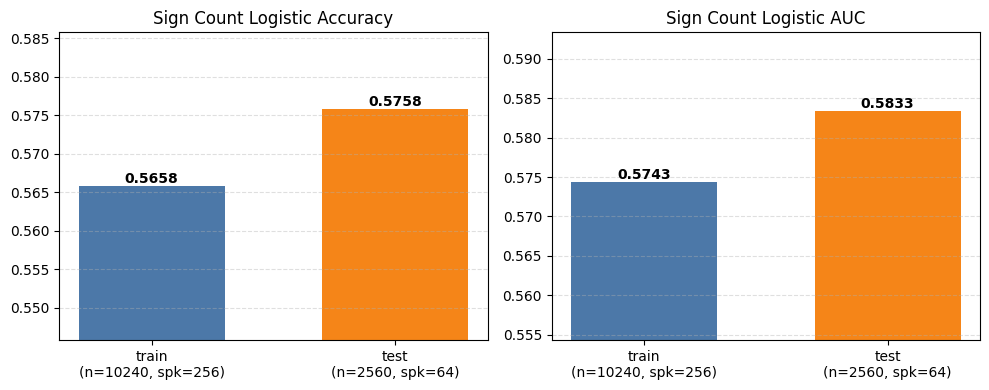

In [6]:
summary_df = pd.DataFrame([
    {
        'split': 'train',
        'accuracy': summary['train_accuracy'],
        'auc': summary['train_auc'],
        'rows': summary['train_rows'],
        'speakers': summary['train_speakers'],
    },
    {
        'split': 'test',
        'accuracy': summary['test_accuracy'],
        'auc': summary['test_auc'],
        'rows': summary['test_rows'],
        'speakers': summary['test_speakers'],
    },
])
display(summary_df)

plot_df = summary_df.copy()
plot_df['label'] = plot_df.apply(lambda r: f"{r['split']}\n(n={int(r['rows'])}, spk={int(r['speakers'])})", axis=1)

metrics = [('accuracy', 'Accuracy'), ('auc', 'AUC')]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (metric, title) in zip(axes, metrics):
    vals = plot_df[metric].astype(float).to_numpy()
    labels = plot_df['label'].tolist()
    ymin = max(0.0, vals.min() - 0.02)
    ymax = min(1.0, vals.max() + 0.01)
    if ymax - ymin < 0.02:
        ymin = max(0.0, vals.min() - 0.01)
        ymax = min(1.0, vals.max() + 0.01)
    bars = ax.bar(labels, vals, color=['#4C78A8', '#F58518'], width=0.6)
    ax.set_title(f'Sign Count Logistic {title}')
    ax.set_ylim(ymin, ymax)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v, f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


In [7]:
coef_df = pd.DataFrame({
    'concept': feature_cols,
    'coef': clf.coef_[0],
})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False).reset_index(drop=True)

print('Intercept:', float(clf.intercept_[0]))
display(coef_df)
display(coef_df.head(10))


Intercept: -0.003383034417245072


,concept,coef,abs_coef
0,short_constant_thick,0.203924,0.203924
1,long_rising_flat_thick,0.147821,0.147821
2,short_dropping_steep_thick,-0.117632,0.117632
3,short_dropping_steep_thin,0.095826,0.095826
4,long_constant_thick,-0.088403,0.088403
5,long_dropping_steep_thick,0.083980,0.083980
6,long_dropping_flat_thick,-0.070034,0.070034
7,short_rising_steep_thick,0.063604,0.063604
8,long_dropping_steep_thin,-0.053055,0.053055
9,long_rising_steep_thick,0.052462,0.052462


,concept,coef,abs_coef
0,short_constant_thick,0.203924,0.203924
1,long_rising_flat_thick,0.147821,0.147821
2,short_dropping_steep_thick,-0.117632,0.117632
3,short_dropping_steep_thin,0.095826,0.095826
4,long_constant_thick,-0.088403,0.088403
5,long_dropping_steep_thick,0.083980,0.083980
6,long_dropping_flat_thick,-0.070034,0.070034
7,short_rising_steep_thick,0.063604,0.063604
8,long_dropping_steep_thin,-0.053055,0.053055
9,long_rising_steep_thick,0.052462,0.052462


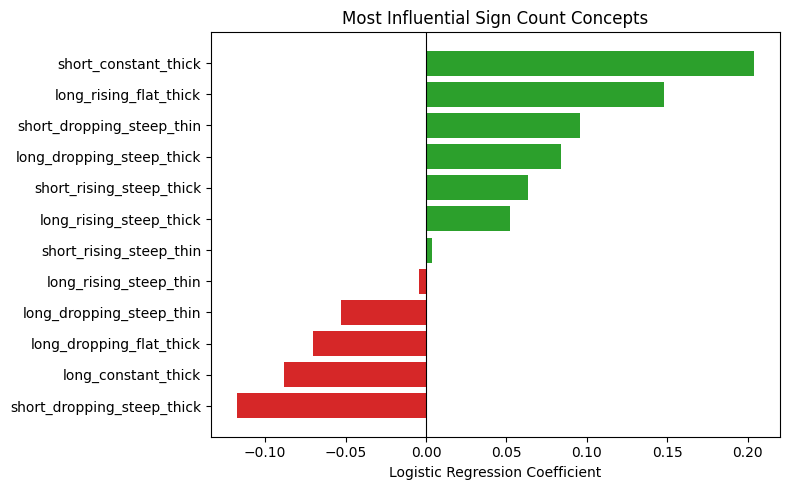

In [8]:
top_df = coef_df.head(12).copy().sort_values('coef')
plt.figure(figsize=(8, 5))
colors = ['#D62728' if v < 0 else '#2CA02C' for v in top_df['coef']]
plt.barh(top_df['concept'], top_df['coef'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Most Influential Sign Count Concepts')
plt.xlabel('Logistic Regression Coefficient')
plt.tight_layout()
plt.show()


In [9]:
with open(MODEL_OUT_DIR / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open(MODEL_OUT_DIR / 'logistic_regression.pkl', 'wb') as f:
    pickle.dump(clf, f)
with open(MODEL_OUT_DIR / 'summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)

coef_df.to_csv(MODEL_OUT_DIR / 'coefficients.csv', index=False)
train_df.to_csv(MODEL_OUT_DIR / 'train_split.csv', index=False)
test_df.to_csv(MODEL_OUT_DIR / 'test_split.csv', index=False)

pred_train = train_df[meta_cols].copy()
pred_train['p_spoof'] = p_tr
pred_train['y_hat'] = yhat_tr
pred_train['split_role'] = 'train'

pred_test = test_df[meta_cols].copy()
pred_test['p_spoof'] = p_te
pred_test['y_hat'] = yhat_te
pred_test['split_role'] = 'test'

pred_df = pd.concat([pred_train, pred_test], axis=0, ignore_index=True)
pred_df.to_csv(MODEL_OUT_DIR / 'predictions.csv', index=False)
split_check_df.to_csv(MODEL_OUT_DIR / 'split_check.csv', index=False)

print('Saved outputs to:', MODEL_OUT_DIR)


Saved outputs to: /home/SpeakerRec/BioVoice/redimnet/tcav/captum_tcav/asvspoof5/output/subset_20spk_20utts_per_spk_one_logistic_head/sign_count_logistic_results
